# Lab 11 — Multiple Access and Modern Air Interfaces (5G NR, Wi-Fi 7)

**Companion to Chapter 11.** Objectives:

1. Compute 5G NR numerology and lay out a slot's resource grid.
2. Schedule users in OFDMA and see why channel-aware scheduling (multi-user
   diversity) beats round robin, and what proportional fairness costs.
3. Show why the uplink uses DFT-s-OFDM: PAPR and power-amplifier back-off.
4. Build link adaptation from the NR MCS table and see HARQ combining gains.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(11)

## 1. NR numerology (TS 38.211)
Subcarrier spacing $\Delta f = 15\cdot 2^{\mu}$ kHz; a slot is always 14 OFDM
symbols (normal CP), so slots shrink as $\mu$ grows. That is how NR scales
latency and phase-noise robustness from 15 kHz at sub-GHz to 120 kHz at mmWave.

In [3]:
print(f"{'mu':>3} {'SCS kHz':>8} {'slot ms':>8} {'symbol us':>10} {'CP us':>7} {'RB kHz':>7}")
for mu in range(0, 5):
    d = cl.nr_numerology(mu)
    print(f"{mu:>3} {d['scs_khz']:>8.0f} {d['slot_ms']:>8.4f} {d['useful_symbol_us']:>10.2f} "
          f"{d['cp_us']:>7.3f} {d['rb_bandwidth_khz']:>7.0f}")

 mu  SCS kHz  slot ms  symbol us   CP us  RB kHz
  0       15   1.0000      66.67   4.688     180
  1       30   0.5000      33.33   2.344     360
  2       60   0.2500      16.67   1.172     720
  3      120   0.1250       8.33   0.586    1440
  4      240   0.0625       4.17   0.293    2880


## 2. A slot's resource grid
One resource block (RB) is 12 subcarriers. Below, a simplified downlink slot
over 4 RBs: PDCCH (control) in the first two symbols, a front-loaded DM-RS in
symbol 2 (type-A mapping), an additional DM-RS in symbol 11 for mobility, and
PDSCH data elsewhere. Every reference signal RE is overhead you pay for channel
estimation (Chapter 7).

Reference-signal + control overhead: 28.0%


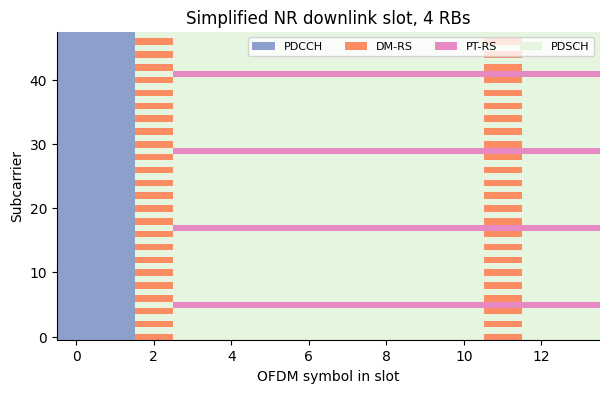

In [5]:
nsc, nsym = 48, 14
grid = np.full((nsc, nsym), 3)                 # 3 = PDSCH
grid[:, :2] = 0                                # PDCCH region
for s in (2, 11):
    grid[::2, s] = 1                           # DM-RS type 1: every other subcarrier
    grid[1::2, s] = 3
grid[5::12, 3:] = np.where(grid[5::12, 3:] == 3, 2, grid[5::12, 3:])   # PT-RS-like tracking pilots
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#8da0cb", "#fc8d62", "#e78ac3", "#e5f5e0"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(grid, aspect="auto", origin="lower", cmap=cmap, interpolation="nearest")
ax.set_xlabel("OFDM symbol in slot"); ax.set_ylabel("Subcarrier")
for lab, col in zip(["PDCCH", "DM-RS", "PT-RS", "PDSCH"], cmap.colors):
    ax.bar(0, 0, color=col, label=lab)
ax.legend(loc="upper right", fontsize=8, ncol=4); ax.set_title("Simplified NR downlink slot, 4 RBs")
ax.grid(False); plt.show()
print(f"Reference-signal + control overhead: {np.mean(grid != 3):.1%}")

## 3. OFDMA scheduling and multi-user diversity
Each user sees an independent frequency-selective channel (TDL 'EVA' at 30 kHz
SCS). Per resource block and slot the scheduler picks one user:

* **Round robin (RR):** ignores the channel.
* **Max-rate:** picks the user with the best instantaneous rate; maximizes cell
  throughput but starves cell-edge users.
* **Proportional fair (PF):** picks $\arg\max_u r_u / \bar{R}_u^{\alpha}$ where
  $\bar{R}_u$ is an exponentially averaged throughput. $\alpha = 1$ is classic PF.

Rates use the Shannon bound with a 3 dB implementation gap.

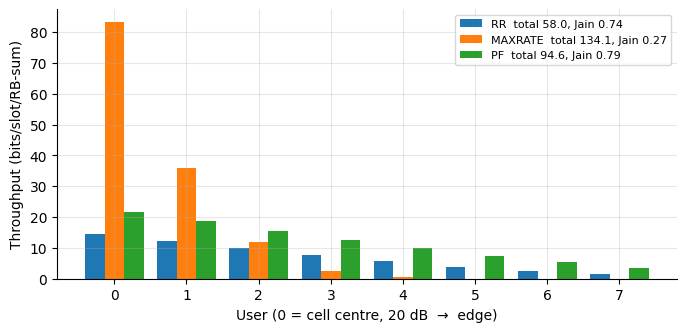

In [7]:
def user_channels(n_users, n_rb, n_slots, mean_snr_db, rng):
    """(slots, users, RBs) SNR from block-fading frequency-selective channels."""
    delays, pdb = cl.TDL_PROFILES["EVA"]
    p = 10 ** (np.array(pdb) / 10); p /= p.sum()
    f_rb = (np.arange(n_rb) * 12 * 30e3)
    snr = np.empty((n_slots, n_users, n_rb))
    for s in range(n_slots):
        g = (rng.standard_normal((n_users, len(p))) + 1j * rng.standard_normal((n_users, len(p)))) * np.sqrt(p / 2)
        H = g @ np.exp(-2j * np.pi * np.outer(np.array(delays) * 1e-9, f_rb))
        snr[s] = (10 ** (np.array(mean_snr_db)[:, None] / 10)) * np.abs(H) ** 2
    return snr

def schedule(snr, policy="pf", alpha=1.0, tc=50):
    S, U, R = snr.shape
    rate = np.log2(1 + snr / 10 ** 0.3)
    avg = np.full(U, 1e-3); served = np.zeros(U)
    for s in range(S):
        inst = np.zeros(U)
        for rb in range(R):
            if policy == "rr":
                u = (s * R + rb) % U
            elif policy == "maxrate":
                u = np.argmax(rate[s, :, rb])
            else:
                u = np.argmax(rate[s, :, rb] / avg ** alpha)
            inst[u] += rate[s, u, rb]
        avg = (1 - 1 / tc) * avg + inst / tc
        served += inst
    return served / S   # bits/s/Hz-per-RB summed per slot

def sched_demo(n_users=8, edge_snr_db=0.0, alpha=1.0):
    mean = np.linspace(20, edge_snr_db, n_users)       # users from cell centre to edge
    snr = user_channels(n_users, 24, 300, mean, rng)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    w = 0.27
    for i, (pol, a) in enumerate([("rr", 1), ("maxrate", 1), ("pf", alpha)]):
        thr = schedule(snr, pol, a)
        ax.bar(np.arange(n_users) + (i - 1) * w, thr, w,
               label=f"{pol.upper()}  total {thr.sum():.1f}, Jain {thr.sum()**2/(n_users*np.sum(thr**2)):.2f}")
    ax.set_xlabel("User (0 = cell centre, 20 dB  →  edge)"); ax.set_ylabel("Throughput (bits/slot/RB-sum)")
    ax.legend(fontsize=8); plt.show()

interact(sched_demo, n_users=IntSlider(value=8, min=2, max=16, description="users"),
         edge_snr_db=FloatSlider(value=0, min=-10, max=20, step=1, description="edge SNR dB"),
         alpha=FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1, description="PF α"));

## 4. Why the NR (and 6G) uplink offers DFT-s-OFDM
A handset PA must be backed off by roughly the signal's PAPR to stay linear.
DFT precoding makes the transmitted signal single-carrier-like, cutting PAPR by
several dB for QPSK; that is uplink coverage. Rel-15 NR allows DFT-s-OFDM for
single-layer uplink; the 6G study (June 2026) agreed to support it with MIMO too.

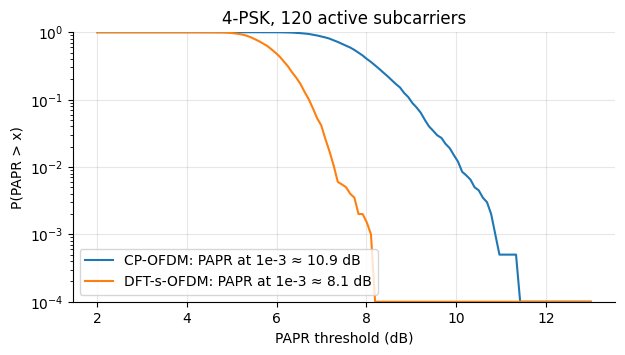

In [9]:
def papr_demo(mod="qpsk", n_used=120):
    cfg = cl.OFDMConfig(nfft=512, n_used=n_used, ncp=36)
    c = cl.get_constellation(mod)
    n_sym = 2000
    sym = c.modulate(cl.random_bits(c.k * n_used * n_sym, rng)).reshape(n_sym, n_used)
    # oversample by 4 via the large FFT (n_used << nfft) so peaks are captured
    x_ofdm = cl.ofdm_modulate(sym, cfg)
    x_dfts = cl.dft_s_ofdm_modulate(sym, cfg)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    for x, lab in [(x_ofdm, "CP-OFDM"), (x_dfts, "DFT-s-OFDM")]:
        p = cl.papr_db(x, cfg.sym_len)
        g, cc = cl.ccdf(p, np.linspace(2, 13, 120))
        ax.semilogy(g, np.maximum(cc, 1e-4), label=f"{lab}: PAPR at 1e-3 ≈ {g[np.argmin(np.abs(cc - 1e-3))]:.1f} dB")
    ax.set_xlabel("PAPR threshold (dB)"); ax.set_ylabel("P(PAPR > x)"); ax.set_ylim(1e-4, 1)
    ax.legend(); ax.set_title(f"{c.name}, {n_used} active subcarriers"); plt.show()

interact(papr_demo, mod=Dropdown(options=["qpsk", "16qam", "64qam", "256qam"], value="qpsk"),
         n_used=IntSlider(value=120, min=12, max=240, step=12, description="subcarriers"));

## 5. Link adaptation with the NR MCS table
The gNB picks a modulation-and-coding scheme from CQI reports to hit about 10%
initial BLER, and HARQ retransmissions clean up the rest. Spectral efficiencies
below are from TS 38.214 Table 5.1.3.1-1 (64-QAM table); the required SNR per MCS
is *modelled* as the Shannon SNR plus a 1.5 dB gap, a common abstraction in
system-level simulators (a real link curve needs link-level simulation, Lab 9).

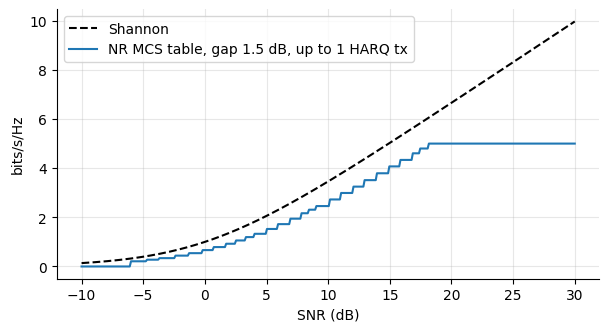

In [11]:
mcs = [(2,120),(2,157),(2,193),(2,251),(2,308),(2,379),(2,449),(2,526),(2,602),(2,679),
       (4,340),(4,378),(4,434),(4,490),(4,553),(4,616),(4,658),(6,438),(6,466),(6,517),
       (6,567),(6,616),(6,666),(6,719),(6,772),(6,822),(6,873),(6,910),(6,948)]
se = np.array([q * r / 1024 for q, r in mcs])
snr_req = 10 * np.log10(2 ** se - 1) + 1.5

def la_demo(gap_db=1.5, harq_tx=1):
    snr = np.linspace(-10, 30, 400)
    req = 10 * np.log10(2 ** se - 1) + gap_db
    # HARQ chase combining: k transmissions add SNR, rate divides by k
    tput = np.zeros_like(snr)
    for k in range(1, harq_tx + 1):
        eff = snr + 10 * np.log10(k)
        idx = np.searchsorted(req, eff, side="right") - 1
        tput = np.maximum(tput, np.where(idx >= 0, se[np.clip(idx, 0, None)] * 0.9 / k, 0))
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(snr, np.log2(1 + 10 ** (snr / 10)), "k--", label="Shannon")
    ax.plot(snr, tput, label=f"NR MCS table, gap {gap_db} dB, up to {harq_tx} HARQ tx")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("bits/s/Hz"); ax.legend(); plt.show()

interact(la_demo, gap_db=FloatSlider(value=1.5, min=0, max=6, step=0.5, description="gap dB"),
         harq_tx=IntSlider(value=1, min=1, max=4, description="max HARQ"));

## 6. Wi-Fi 7's 4096-QAM: an EVM budget exercise
4096-QAM carries 12 bits per symbol. The transmitter EVM limit for the top
802.11be MCS is about −38 dB. Below: uncoded BER of 4096-QAM versus the combined
SNR, where transmitter EVM and receiver noise add as powers:
$\mathrm{SNR}_{\mathrm{eff}}^{-1} = \mathrm{EVM}^2 + \mathrm{SNR}_{\mathrm{rx}}^{-1}$.

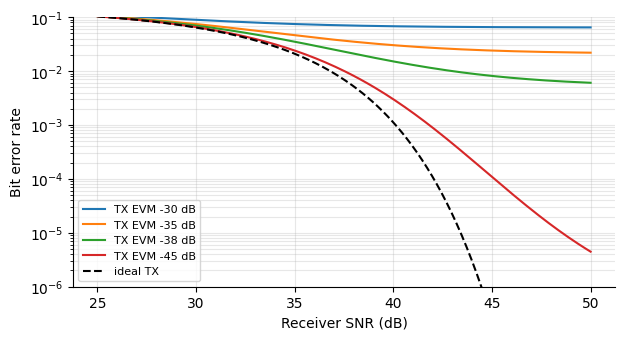

In [13]:
snr_rx = np.linspace(25, 50, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for evm_db in [-30, -35, -38, -45]:
    eff = -10 * np.log10(10 ** (evm_db / 10) + 10 ** (-snr_rx / 10))
    ax.semilogy(snr_rx, cl.ber_mqam_gray(eff, 4096), label=f"TX EVM {evm_db} dB")
ax.semilogy(snr_rx, cl.ber_mqam_gray(snr_rx, 4096), "k--", label="ideal TX")
cl.ber_axes(ax, "Receiver SNR (dB)"); ax.set_ylim(1e-6, 0.1); ax.legend(fontsize=8); plt.show()

## Exercises

1. **(Warm-up)** For $\mu = 1$ and 273 RBs, compute the occupied bandwidth and
   the guard-band fraction of a 100 MHz carrier.
2. **(Core)** In the scheduler, sweep PF's α from 0 to 3 and plot total
   throughput against Jain's fairness index. Explain the trade-off curve.
3. **(Core)** Add clipping-and-filtering PAPR reduction to CP-OFDM. How much
   PAPR can you remove before EVM exceeds −25 dB (the 64-QAM requirement)?
4. **(Stretch)** Replace the SNR-gap abstraction with an EESM
   (exponential effective SINR mapping) over a frequency-selective channel and
   compare the chosen MCS with the flat-channel choice.